In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
care = pd.read_csv('C:/Users/clare/Downloads/Trainingprojects/healthcare_dataset.csv')

In [9]:
print(care.dtypes)

Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object


In [11]:
print(care.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [13]:
care['Name'] = care['Name'].str.title()
print(care['Name'].head(10))

0         Bobby Jackson
1          Leslie Terry
2           Danny Smith
3          Andrew Watts
4         Adrienne Bell
5         Emily Johnson
6        Edward Edwards
7    Christina Martinez
8       Jasmine Aguilar
9      Christopher Berg
Name: Name, dtype: object


In [15]:
care['Date of Admission'] = pd.to_datetime(care['Date of Admission'], dayfirst=True)
care['Admission Year'] = care['Date of Admission'].dt.year
print(care['Date of Admission'].dtype)
print(care['Admission Year'].value_counts().sort_index())

datetime64[ns]
2019     7387
2020    11285
2021    10931
2022    11017
2023    11026
2024     3854
Name: Admission Year, dtype: int64


In [17]:
# Impossible values
print('Negative ages:', (care['Age'] < 0).sum())
print('Ages over 120:', (care['Age'] > 120).sum())
print('Negative billing:', (care['Billing Amount'] < 0).sum())

# Unique categories
print('\nGender values:', care['Gender'].unique())
print('Admission types:', care['Admission Type'].unique())
print('Test results:', care['Test Results'].unique())

Negative ages: 0
Ages over 120: 0
Negative billing: 108

Gender values: ['Male' 'Female']
Admission types: ['Urgent' 'Emergency' 'Elective']
Test results: ['Normal' 'Inconclusive' 'Abnormal']


In [19]:
# Age and Billing Amount are the key numeric columns
for col in ['Age', 'Billing Amount']:
    Q1 = care[col].quantile(0.25)
    Q3 = care[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = care[(care[col] < lower) | (care[col] > upper)]
    print(f'\n{col} outliers: {len(outliers)}')
    print(f'Lower bound: {lower:.2f}, Upper bound: {upper:.2f}')
    print(f'Min: {care[col].min()}, Max: {care[col].max()}')


Age outliers: 0
Lower bound: -14.50, Upper bound: 117.50
Min: 13, Max: 89

Billing Amount outliers: 0
Lower bound: -23627.70, Upper bound: 74689.43
Min: -2008.4921398591305, Max: 52764.276736469175


In [19]:
# Show all negative billing rows
negative_billing = care[care['Billing Amount'] < 0]
print(f'Total negative billing rows: {len(negative_billing)}')
print(negative_billing[['Name', 'Billing Amount', 
                          'Hospital', 'Medical Condition']].to_string())

Total negative billing rows: 108
                           Name  Billing Amount                           Hospital Medical Condition
132             Ashley Erickson     -502.507813          and Johnson Moore, Branch            Cancer
799           Christopher Weiss    -1018.245371                      Hunter-Hughes            Asthma
1018              Ashley Warner     -306.364925              and Wagner, Lee Klein      Hypertension
1421               Jay Galloway     -109.097122                       Group Peters            Asthma
2103          Joshua Williamson     -576.727907            and Huff Reeves, Dennis          Diabetes
2696              Scott Vazquez     -135.986000                          James Ltd          Diabetes
2855             Carol Anderson     -370.983674       Carter Carter, and Patterson      Hypertension
3772   Mr. Christopher Alvarado    -1310.272895                        Johnson Inc           Obesity
5445             Alexandra Khan     -692.408820           

In [21]:
# Document the issue
print(f'Total rows original: {len(care)}')
print(f'Negative billing rows removed: {len(care[care["Billing Amount"] < 0])}')

# Remove negative billing rows
care_clean = care[care['Billing Amount'] > 0].copy()
print(f'Clean dataset rows: {len(care_clean)}')
print(f'Percentage removed: {108/len(care)*100:.2f}%')

Total rows original: 55500
Negative billing rows removed: 108
Clean dataset rows: 55392
Percentage removed: 0.19%


In [ ]:
# DATA QUALITY NOTE: 108 rows with negative billing amounts removed
# These represent random data entry errors across multiple hospitals
# and conditions. Removal represents 0.19% of total dataset.
# All subsequent analysis uses care_clean (55,392 rows)

In [23]:
# Query 1 - Year with highest admissions
year_admissions = care_clean.groupby( 'Admission Year')['Name'].count().reset_index()
year_admissions.columns = ['Year', 'Total Admissions']
year_admissions = year_admissions.sort_values('Total Admissions', ascending=False)

print('=== YEAR WITH HIGHEST ADMISSIONS ===')
print(year_admissions)
print(f'\nAnswer: {year_admissions.iloc[0]["Year"]} with {year_admissions.iloc[0]["Total Admissions"]:,} admissions')

=== YEAR WITH HIGHEST ADMISSIONS ===
   Year  Total Admissions
1  2020             11270
4  2023             11008
3  2022             10993
2  2021             10910
0  2019              7365
5  2024              3846

Answer: 2020 with 11,270 admissions


In [25]:
# Query 2 - Medical condition with highest admissions
condition_admissions = care_clean.groupby('Medical Condition')['Name'].count().reset_index()
condition_admissions.columns = ['Medical Condition', 'Total Admissions']
condition_admissions = condition_admissions.sort_values('Total Admissions', ascending=False)

print('=== MEDICAL CONDITION WITH HIGHEST ADMISSIONS ===')
print(condition_admissions)
print(f'\nAnswer: {condition_admissions.iloc[0]["Medical Condition"]} with {condition_admissions.iloc[0]["Total Admissions"]:,} admissions')

=== MEDICAL CONDITION WITH HIGHEST ADMISSIONS ===
  Medical Condition  Total Admissions
0         Arthritis              9297
3          Diabetes              9284
4      Hypertension              9224
5           Obesity              9212
2            Cancer              9208
1            Asthma              9167

Answer: Arthritis with 9,297 admissions


In [27]:
# Query 3 - Hospital with highest admissions
hospital_admissions = care_clean.groupby('Hospital')['Name'].count().reset_index()
hospital_admissions.columns = ['Hospital', 'Total Admissions']
hospital_admissions = hospital_admissions.sort_values('Total Admissions', ascending=False)

print('=== HOSPITAL WITH HIGHEST ADMISSIONS ===')
print(hospital_admissions)
print(f'\nAnswer: {hospital_admissions.iloc[0]["Hospital"]} with {hospital_admissions.iloc[0]["Total Admissions"]:,} admissions')

=== HOSPITAL WITH HIGHEST ADMISSIONS ===
                           Hospital  Total Admissions
16849                     LLC Smith                44
18556                     Ltd Smith                39
14844                   Johnson PLC                38
28842                     Smith Ltd                37
28862                     Smith PLC                36
...                             ...               ...
14719      Jimenez Roy, Johnson and                 1
14716        Jimenez Logan Lee, and                 1
14714   Jimenez Humphrey and Evans,                 1
14713  Jimenez Henry and Henderson,                 1
39814    and Zuniga Thompson, Blake                 1

[39815 rows x 2 columns]

Answer: LLC Smith with 44 admissions


In [ ]:
#Hospital names in this dataset appear to be randomly generated with 39,876 unique values across 55,500 records. 
#Individual hospital analysis is not meaningful. 
#Hospital entity type was extracted as a proxy grouping variable for exploratory purposes only."

In [29]:
# Query 4 - Average billing amount by medical condition
billing_condition = care_clean.groupby('Medical Condition')['Billing Amount'].mean().reset_index()
billing_condition.columns = ['Medical Condition', 'Avg Billing Amount']
billing_condition['Avg Billing Amount'] = billing_condition['Avg Billing Amount'].round(2)
billing_condition = billing_condition.sort_values('Avg Billing Amount', ascending=False)

print('=== AVERAGE BILLING BY MEDICAL CONDITION ===')
print(billing_condition)
print(f'\nHighest: {billing_condition.iloc[0]["Medical Condition"]} at £{billing_condition.iloc[0]["Avg Billing Amount"]:,}')

=== AVERAGE BILLING BY MEDICAL CONDITION ===
  Medical Condition  Avg Billing Amount
5           Obesity            25860.32
3          Diabetes            25694.50
1            Asthma            25686.67
4      Hypertension            25556.09
0         Arthritis            25528.12
2            Cancer            25214.91

Highest: Obesity at £25,860.32


In [31]:
# Query 5 - Insurance provider with most patients
insurance_count = care_clean.groupby('Insurance Provider')['Name'].count().reset_index()
insurance_count.columns = ['Insurance Provider', 'Total Patients']
insurance_count = insurance_count.sort_values('Total Patients', ascending=False)

print('=== INSURANCE PROVIDER WITH MOST PATIENTS ===')
print(insurance_count)
print(f'\nAnswer: {insurance_count.iloc[0]["Insurance Provider"]} with {insurance_count.iloc[0]["Total Patients"]:,} patients')

=== INSURANCE PROVIDER WITH MOST PATIENTS ===
  Insurance Provider  Total Patients
2              Cigna           11225
3           Medicare           11132
4   UnitedHealthcare           11106
1         Blue Cross           11043
0              Aetna           10886

Answer: Cigna with 11,225 patients


In [33]:
care_clean['age_group'] = pd.cut(care_clean['Age'],
    bins=[0, 17, 34, 49, 64, 100],
    labels=['0-17', '18-34', '35-49', '50-64', '65+'])

print(care_clean['age_group'].value_counts().sort_index())

0-17       116
18-34    13577
35-49    12258
50-64    12388
65+      17053
Name: age_group, dtype: int64


In [35]:
# Query 6 - Most common admission type by age group
admission_age = care_clean.groupby(['age_group', 'Admission Type'])['Name'].count().reset_index()
admission_age.columns = ['Age Group', 'Admission Type', 'Count']
admission_age = admission_age.sort_values(['Age Group', 'Count'], ascending=[True, False])

print('=== ADMISSION TYPE BY AGE GROUP ===')
print(admission_age.to_string(index=False))

=== ADMISSION TYPE BY AGE GROUP ===
Age Group Admission Type  Count
     0-17      Emergency     48
     0-17       Elective     34
     0-17         Urgent     34
    18-34       Elective   4554
    18-34         Urgent   4512
    18-34      Emergency   4511
    35-49       Elective   4171
    35-49         Urgent   4145
    35-49      Emergency   3942
    50-64       Elective   4238
    50-64         Urgent   4105
    50-64      Emergency   4045
      65+         Urgent   5742
      65+      Emergency   5690
      65+       Elective   5621


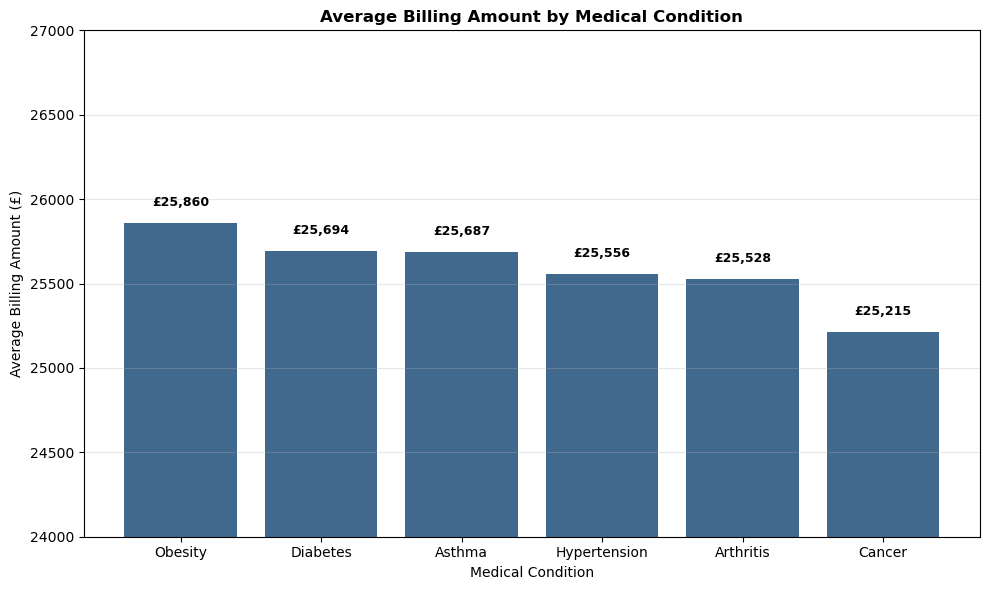

Chart 1 saved!


In [44]:
# CHART 1 - Average Billing by Medical Condition
plt.figure(figsize=(10, 6))
bars = plt.bar(billing_condition['Medical Condition'],
               billing_condition['Avg Billing Amount'],
               color='#1f4e79', alpha=0.85)

for bar, val in zip(bars, billing_condition['Avg Billing Amount']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'£{val:,.0f}',
             ha='center', fontsize=9, fontweight='bold')

plt.title('Average Billing Amount by Medical Condition',
          fontweight='bold')
plt.xlabel('Medical Condition')
plt.ylabel('Average Billing Amount (£)')
plt.ylim(24000, 27000)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('C:/Users/clare/Downloads/billing_by_condition.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved!')

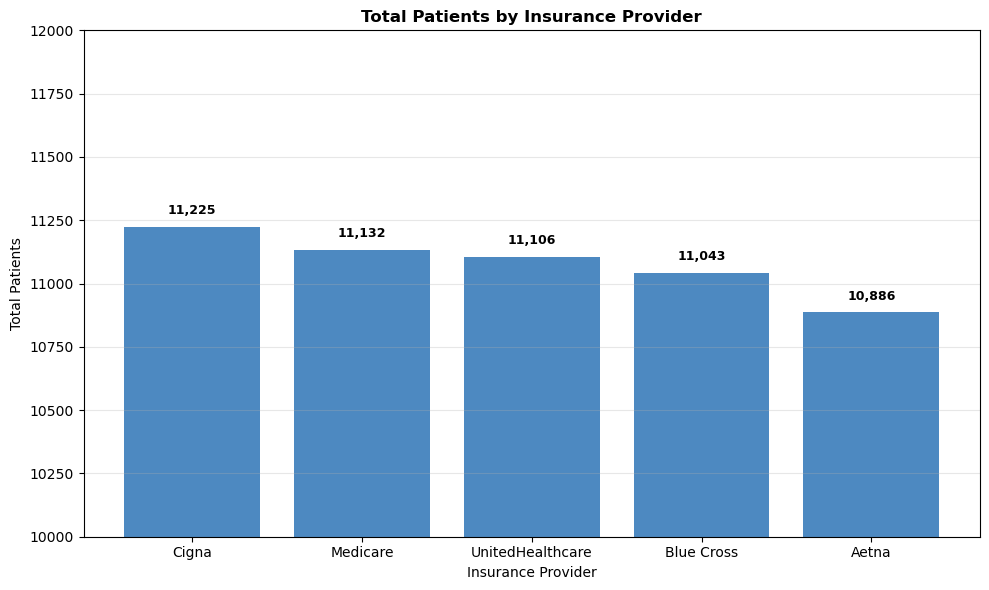

Chart 2 saved!


In [37]:
# CHART 2 - Insurance Provider with Most Patients
plt.figure(figsize=(10, 6))
bars = plt.bar(insurance_count['Insurance Provider'],
               insurance_count['Total Patients'],
               color='#2e75b6', alpha=0.85)

for bar, val in zip(bars, insurance_count['Total Patients']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{val:,}',
             ha='center', fontsize=9, fontweight='bold')

plt.title('Total Patients by Insurance Provider',
          fontweight='bold')
plt.xlabel('Insurance Provider')
plt.ylabel('Total Patients')
plt.ylim(10000, 12000)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('C:/Users/clare/Downloads/insurance_provider.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved!')

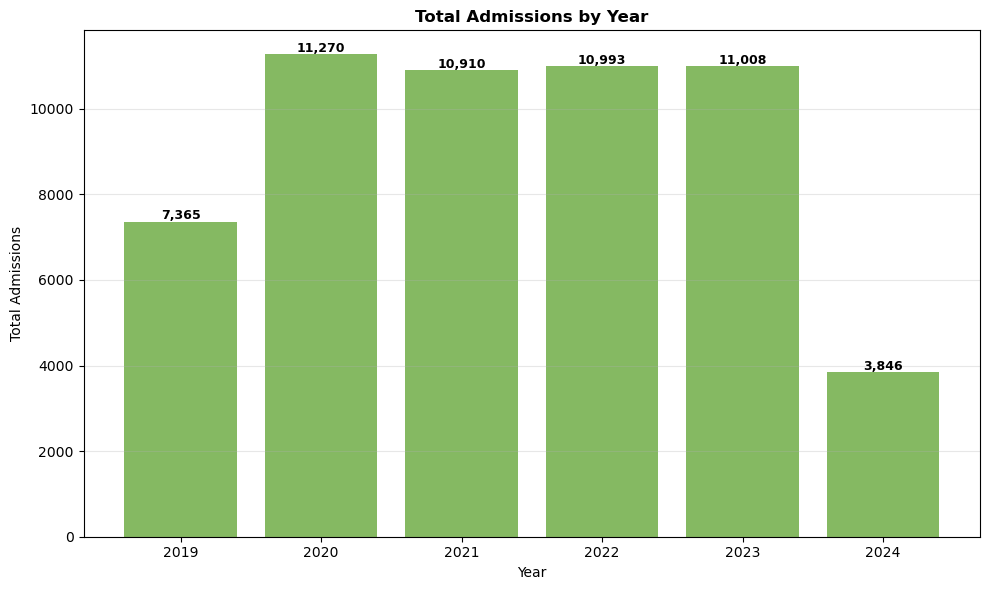

Chart 3 saved!


In [49]:
# CHART 3 - Year with Highest Admissions
plt.figure(figsize=(10, 6))
bars = plt.bar(year_admissions['Year'],
               year_admissions['Total Admissions'],
               color='#70ad47', alpha=0.85)

for bar, val in zip(bars, year_admissions['Total Admissions']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{val:,}',
             ha='center', fontsize=9, fontweight='bold')

plt.title('Total Admissions by Year',
          fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Admissions')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('C:/Users/clare/Downloads/admissions_by_year.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved!')

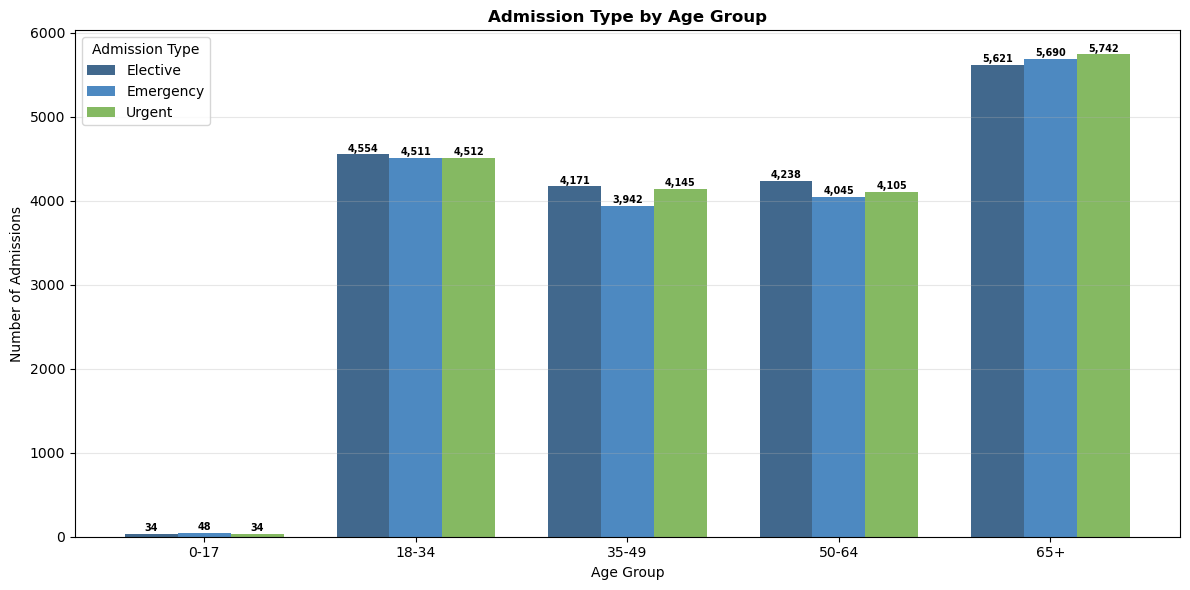

Chart 4 saved!


In [39]:
# CHART 4 - Admission Type by Age Group (Grouped Bar Chart)
import numpy as np

admission_pivot = admission_age.pivot(
    index='Age Group',
    columns='Admission Type',
    values='Count').fillna(0)

x = np.arange(len(admission_pivot.index))
width = 0.25
colors = ['#1f4e79', '#2e75b6', '#70ad47']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (col, color) in enumerate(
        zip(admission_pivot.columns, colors)):
    bars = ax.bar(x + i * width,
                  admission_pivot[col],
                  width, label=col,
                  color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 30,
                f'{int(bar.get_height()):,}',
                ha='center', fontsize=7,
                fontweight='bold')

ax.set_title('Admission Type by Age Group',
             fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Number of Admissions')
ax.set_xticks(x + width)
ax.set_xticklabels(admission_pivot.index)
ax.legend(title='Admission Type')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('C:/Users/clare/Downloads/admission_by_age.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved!')

In [41]:
# Save clean dataset for Power BI and GitHub
care_clean.to_csv('C:/Users/clare/Downloads/healthcare_clean.csv', 
                   index=False)
print('Clean dataset saved!')

Clean dataset saved!
